# Test different CNN architectures provided in `Landmine Detection Using Autoencoders on  Multipolarization GPR Volumetric Data` article

# Передмова
Для тесту будуть братись 3 різні архітектури згорткових мереж для 3 різних способів передачі даних

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import json
import os

## Базові параметри що будуть спільними для всіх
- **Розмір патча (висота х ширина):** 176х32. Треба додати 6 пустих відліків до оригінальної глибини, щоб глибина ідеально ділилася на 2 під час стиснення. Вікно шириною 32 траси ковзає вздовж профілю на 440 трас із кроком 17.
- **Оптимізатор:*** Adam
- **Функція активації на виході:** `tanh` (важливо щоб всі вхідні дані були в діапазоні [-1,1])
- **Архітектури стиснення:** Для кожної з категорій нижче ми проженемо три варіанти згортки:
    - **A1:** Стиснення в 16 разів (найбільше деталей).
    - **A2:** Стиснення в 32 рази.
    - **A3:** Стиснення в 64 рази (екстримальна компресія, залишає лише загальну геометрію ґрунту).

### Тестування
Індекатором аномалії буде (Reconstruction Error) із оцінкою MSE (Mean Square Error) та MAE (Mean Absolute Error) між оригінальним патчем та тим, що згенерував декодер.

- **Етап А: Тренування (Baseline)**<br>
Моделі згодовується набір даних відповідної розмірності. На цьому етапі особлива увага приділяється лише графіку Loss. Якщо Loss падає і стабілізується на низькому рівні - модель успішно вивчила фізику ґрунту. Якщо Loss залишається високим (що ймовірно для жорсткого стиснення А3) - модель не здатна відтворити навіть фон.
- **Етап Б: Інферренс (Тест на даних із "аномаліями")**<br>
Береться тестовий В-скан **із міною** (з тієї частини датасету, на якій не проходило тренування). Пропускається ковзне вікно через цей В-скан (25 патчів). Розраховується загальний `MSE`
- **Етап В: Аналіз графіку помилок**<br>
Будується графік (вісь Х - номери патчів від 1 до 25, Y - значення помилки `MSE`).


**Найкраща модель**<br>
Найкращою архітектурою буде та, що дає найбільшу *дельту* між середньою помилкою на фонових патчах та піковою помилкою на аномальному патчі.


### Зберігання результатів
Нижче описані функції для зберігання результатів роботи мереж в JSON файл для подальшого аналізу

In [2]:
RESULTS_FILE = './gpr_full_project_results.json'

def init_full_results_storage(filename=RESULTS_FILE):
    """
    Ініціалізує єдиний JSON-файл для всіх моделей проєкту.
    """
    if os.path.exists(filename):
        with open(filename, 'r', encoding='utf-8') as f:
            print(f"Файл {filename} знайдено. Завантажуємо існуючу структуру.")
            return json.load(f)
            
    # Базовий каркас для всіх конфігурацій
    base_structure = {
        "metadata": {
            "window_size": 32,
            "step": 17,
            "epochs": 50,
            "learning_rate": 0.001,
            "optimizer": "Adam",
            "loss_function": "MSELoss"
        },
        "results": {
            "1_channel": {
                "A1_x16": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []},
                "A2_x32": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []},
                "A3_x64": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []}
            },
            "3_channel": {
                "A1_x16": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []},
                "A2_x32": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []},
                "A3_x64": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []}
            },
            "5_channel": {
                "A1_x16": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []},
                "A2_x32": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []},
                "A3_x64": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []}
            }
        }
    }
    
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(base_structure, f, indent=4)
    print(f"Створено новий глобальний файл {filename} для всіх 9 моделей.")
    
    return base_structure

def save_model_results(channel_type, model_key, train_loss, test_img_mse, test_lat_mse, filename=RESULTS_FILE):
    """
    Зберігає результати у відповідну секцію (наприклад: '1_channel', 'A1_x16').
    """
    with open(filename, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    # Перевірка на дурня
    if channel_type not in data["results"]:
        raise ValueError(f"Секції {channel_type} не існує! Використовуй 1_channel, 3_channel або 5_channel")
    if model_key not in data["results"][channel_type]:
        raise ValueError(f"Моделі {model_key} не існує в секції {channel_type}!")

    # Записуємо масиви
    data["results"][channel_type][model_key]["train_loss"] = train_loss
    data["results"][channel_type][model_key]["test_image_mse"] = test_img_mse
    data["results"][channel_type][model_key]["test_latent_mse"] = test_lat_mse
    
    # Зберігаємо на диск
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=4)
        
    print(f"✅ Результати збережено: [{channel_type} -> {model_key}]")

# ==========================================
# ІНІЦІАЛІЗАЦІЯ
# ==========================================
results_db = init_full_results_storage()

Файл ./gpr_full_project_results.json знайдено. Завантажуємо існуючу структуру.


### Допоміжні функції<br>
- `plot_comparison_from_json` - Витягує інформацію про експеремент в певному режимі (1, 3 або 5 каналів) та виводить на спільному графіку криві похибки *Z1 - Z2*<br>

In [49]:
def plot_comparison_from_json(json_file, channel_type='1_channel', anomaly_start=19, anomaly_end=23):
    """
    Читає JSON-базу і будує зведений графік Latent MSE для всіх моделей 
    у межах заданої категорії каналів.
    """
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"❌ Файл {json_file} не знайдено.")
        return

    if channel_type not in data.get('results', {}):
        print(f"❌ Секцію {channel_type} не знайдено в JSON.")
        return
        
    models_data = data['results'][channel_type]
    
    plt.figure(figsize=(15, 7))
    
    # Хардкодимо стилі для стабільної візуалізації (щоб кольори не стрибали при перезапусках)
    styles = {
        'A1_x16': {'marker': 'o', 'color': 'red', 'label': 'A1 (x16)'},
        'A2_x32': {'marker': 's', 'color': 'green', 'label': 'A2 (x32)'},
        'A3_x64': {'marker': '^', 'color': 'blue', 'label': 'A3 (x64)'}
    }
    
    max_len = 0
    plotted_any = False
    
    for model_key, metrics in models_data.items():
        lat_mse = metrics.get('test_latent_mse', [])
        
        if not lat_mse:
            print(f"⚠️ Для моделі {model_key} немає даних test_latent_mse. Пропускаємо.")
            continue
            
        x_axis = np.arange(1, len(lat_mse) + 1)
        max_len = max(max_len, len(lat_mse))
        plotted_any = True
        
        # Беремо стиль або генеруємо дефолтний, якщо з'явиться нова модель
        style = styles.get(model_key, {'marker': 'x', 'color': 'black', 'label': model_key})
        
        plt.plot(x_axis, lat_mse, marker=style['marker'], color=style['color'], 
                 linewidth=2, alpha=0.8, label=style['label'])

    if plotted_any:
        # Виділяємо зону міни
        plt.axvspan(anomaly_start, anomaly_end, color='gray', alpha=0.15, 
                    label=f'Фактична міна (Вікна {anomaly_start}-{anomaly_end})')
        
        plt.title(f"Порівняння архітектур ({channel_type}): Latent Error $Z_1 - Z_2$")
        plt.xlabel("Номер патча (Вікно ковзає по профілю)")
        plt.ylabel("Рівень аномальності (MSE)")
        plt.xticks(np.arange(1, max_len + 1, step=1))
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(loc='upper left', fontsize='11')
        plt.tight_layout()
        plt.show()
    else:
        print("❌ Немає валідних даних для побудови графіка.")

- `evaluate_anomaly_detector` - Тестує модель на даних та підраховує Image MSE та Latent MSE
$$ \text{Image MSE} = X - \hat{X} $$
$$ \text{Latent MSE} = Z_1 - Z_2 $$

- `plot_model_metrics` - Будує подвійний графік навчання та відображення Image MSE та Latent MSE<br>
- `plot_bscan_with_prediction` - Малює теплову карту аномальності. Усі вікна підсвічуються червоним, але інтенсивність (alpha) залежить від висоти помилки у цьому вікні. Ground Truth вимкнено за замовчуванням.<br>
- `plot_reconstruction_sample` - Виводить порівняння оригінального патчу та відтвореного

In [ ]:
# ==========================================
# УТИЛІТИ ДЛЯ ОЦІНКИ ТА ВІЗУАЛІЗАЦІЇ
# ==========================================

def evaluate_anomaly_detector(model, dataloader, device, criterion):
    """
    Проганяє тестовий датасет через модель і рахує Image MSE та Latent MSE.
    Повертає два списки з помилками.
    """
    model.eval()
    img_mse_list = []
    lat_mse_list = []
    
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            x_hat, z1, z2 = model(batch)
            
            img_mse_list.append(criterion(x_hat, batch).item())
            lat_mse_list.append(criterion(z1, z2).item())
            
    return img_mse_list, lat_mse_list

def plot_model_metrics(train_loss, img_mse, lat_mse, model_name, anomaly_win_start=19, anomaly_win_end=23):
    """
    Будує стандартний подвійний графік: падіння Loss та результати інференсу.
    """
    plt.figure(figsize=(14, 5))

    # 1. Графік тренування
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, color='blue', linewidth=2)
    plt.title(f"{model_name}: Тренувальний Loss")
    plt.xlabel("Епохи")
    plt.ylabel("MSE")
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2. Графік інференсу
    plt.subplot(1, 2, 2)
    x_axis = np.arange(1, len(lat_mse) + 1)
    
    # Визначаємо маркер залежно від моделі для консистентності
    marker_style = 'o' if 'A1' in model_name else ('s' if 'A2' in model_name else '^')
    color_style = 'red' if 'A1' in model_name else ('green' if 'A2' in model_name else 'blue')
    
    plt.plot(x_axis, lat_mse, marker=marker_style, color=color_style, label='Latent MSE ($Z_1 - Z_2$)')
    plt.plot(x_axis, img_mse, marker='x', color='orange', alpha=0.6, label='Image MSE')

    # Підсвітка зони
    plt.axvspan(anomaly_win_start, anomaly_win_end, color='gray', alpha=0.15, label='Фактична міна')

    plt.title(f"{model_name}: Інференс (Тестовий B-scan)")
    plt.xlabel("Номер патча (Вікно)")
    plt.ylabel("Рівень помилки")
    plt.xticks(np.arange(1, len(lat_mse) + 1, step=2))
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

def plot_bscan_with_prediction(tensor_data, lat_mse, window_size=32, step=17, true_start=None, true_end=None, title="Тестовий B-scan"):
    """
    Малює теплову карту аномальності. Усі вікна підсвічуються червоним, 
    але інтенсивність (alpha) залежить від висоти помилки у цьому вікні.
    Ground Truth вимкнено за замовчуванням.
    """
    # Переводимо тензор у 2D масив NumPy
    if torch.is_tensor(tensor_data):
        bscan_2d = tensor_data.squeeze().cpu().numpy()
    else:
        bscan_2d = np.squeeze(tensor_data)
        
    plt.figure(figsize=(15, 6))
    img = plt.imshow(bscan_2d, aspect='auto', cmap='gray', vmin=-1, vmax=1)
    plt.grid(color='cyan', linestyle='--', linewidth=0.5, alpha=0.3)

    # 1. Нормалізація масиву помилок для розрахунку прозорості (Alpha)
    mse_array = np.array(lat_mse)
    min_err = np.min(mse_array)
    max_err = np.max(mse_array)
    
    # Захист від ділення на нуль (випадок "мертвої" мережі A3)
    if max_err > min_err:
        norm_mse = (mse_array - min_err) / (max_err - min_err)
    else:
        norm_mse = np.zeros_like(mse_array)

    # 2. Малюємо кожне вікно з відповідною інтенсивністю
    max_alpha = 0.5 # Максимальна непрозорість для найвищого спайку
    
    for i, val in enumerate(norm_mse):
        start = i * step
        end = start + window_size
        
        # Рахуємо альфу для поточного вікна
        alpha_val = val * max_alpha
        
        # Малюємо тільки якщо є хоч якась помітна помилка, щоб не перевантажувати рендер
        if alpha_val > 0.05:
            plt.axvspan(start, end, color='red', alpha=alpha_val, lw=0)

    # 3. Малюємо Ground Truth ТІЛЬКИ якщо передані координати
    if true_start is not None and true_end is not None:
        plt.axvspan(true_start, true_end, facecolor='none', edgecolor='green', 
                    linewidth=2, linestyle='--', label='Фактична міна (GT)')
        plt.legend(loc='upper right')

    plt.colorbar(img, label='Нормалізована амплітуда [-1, 1]')
    plt.title(title)
    plt.xlabel("Номер траси (Вісь X - просування радара)")
    plt.ylabel("Глибина (Вісь Z)")
    plt.tight_layout()
    plt.show()

def plot_reconstruction_sample(model, dataset, device, patch_idx, title_prefix=""):
    """
    Бере конкретний патч із датасету, проганяє через модель і малює 
    оригінал та те, що відновив декодер (x_hat), пліч-о-пліч.
    """
    model.eval()
    
    # Витягуємо патч (він має розмір [1, 176, 32])
    # Додаємо вимір батчу (unsqueeze), щоб стало [1, 1, 176, 32]
    original_patch = dataset[patch_idx].unsqueeze(0).to(device)
    
    with torch.no_grad():
        x_hat, _, _ = model(original_patch)
        
    # Переводимо тензори в NumPy 2D масиви для малювання
    orig_img = original_patch.squeeze().cpu().numpy()
    recon_img = x_hat.squeeze().cpu().numpy()
    
    # Рахуємо локальну помилку для заголовка
    mse_error = np.mean((orig_img - recon_img) ** 2)
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 6))
    
    # Малюємо оригінал
    im1 = axes[0].imshow(orig_img, aspect='auto', cmap='gray', vmin=-1, vmax=1)
    axes[0].set_title("Оригінал (Вхід X)")
    axes[0].set_ylabel("Глибина")
    axes[0].set_xlabel("Траси (Ширина 32)")
    
    # Малюємо реконструкцію
    im2 = axes[1].imshow(recon_img, aspect='auto', cmap='gray', vmin=-1, vmax=1)
    axes[1].set_title(rf"Реконструкція (Вихід $\hat{{X}}$)\nMSE: {mse_error:.5f}")
    axes[1].set_xlabel("Траси (Ширина 32)")
    
    plt.suptitle(f"{title_prefix} - Патч №{patch_idx+1}")
    plt.tight_layout()
    plt.show()

### Підготовка даних
Для тренування буде зібраний 3D масив із зрізів чистого грунту (без аномалій) розмірністю 12x170x440 (надалі доповнений до 12x176x440) 

In [4]:
file_path = '../datasets/giuriati_2/20170621_deg0_HHVV.npy'
full_data = np.load(file_path, allow_pickle=True).item()

In [5]:
data = full_data['data']
gt = full_data['ground_truth']

In [6]:
print("-" * 40)
print(f"Вміст словника (ключі): {list(full_data.keys())}")
print(f"Розмірність матриці даних (Shape): {np.shape(data)}")
print(f"Розмірність розмітки (Ground Truth): {np.shape(gt)}")
print(f"Мінімальне значення: {data.min():.4f}")
print(f"Максимальне значення: {data.max():.4f}")
print("-" * 40)

----------------------------------------
Вміст словника (ключі): ['param', 'data', 'ground_truth']
Розмірність матриці даних (Shape): (66, 170, 440)
Розмірність розмітки (Ground Truth): (66,)
Мінімальне значення: -2.6768
Максимальне значення: 3.0877
----------------------------------------


In [7]:
# Очистка датасету від даних з "аномаліями"
# Отримання індексів В-сканів без аномалій
clean_indices = np.where(gt == 0)[0]
print(f"Оригінальні індекси чистих ліній: {clean_indices}")

# Отримання чистих даних
clean_data = data[clean_indices]
print(f"Розмірність сирого тренувального тензора: {clean_data.shape}")

Оригінальні індекси чистих ліній: [ 0  1  2  3  4  5  6  7  8 20 21 22]
Розмірність сирого тренувального тензора: (12, 170, 440)


#### Нормалізація датасету (Time-Varying Gain, Background Removal, Normalization)
Для деталей дивитись [обробка даних](./landmineDetectionDataReview.ipynb)

In [8]:

# Background Removal
mean_traces = np.mean(clean_data, axis=2, keepdims=True)
bg_removed = clean_data - mean_traces

# TVG
alpha = 0.015 
depth_indices = np.arange(clean_data.shape[1])
gain_curve = np.exp(alpha * depth_indices).reshape(1, -1, 1) 
tvg_applied = bg_removed * gain_curve

# Глобальна нормалізація відносно всього тренувального сету
max_val = np.max(np.abs(tvg_applied))
clean_norm = tvg_applied / max_val

In [9]:
# PADDING ДЛЯ АВТОЕНКОДЕРА (170 -> 176)
# Додаємо 6 рядків знизу (по осі 1). 
# Використовуємо mode='edge' (дублювання останнього рядка), а не нулі! 
# Раптові нулі створять штучний "обрив", який CNN сприйме як величезну аномалію на дні.
pad_width = ((0, 0), (0, 6), (0, 0)) # (лінії, глибина, траси)
train_tensor = np.pad(clean_norm, pad_width, mode='edge')

print("-" * 40)
print(f"Фінальний тензор для нарізки (Train): {train_tensor.shape}")
print(f"Мінімум: {train_tensor.min():.4f}, Максимум: {train_tensor.max():.4f}")
print("-" * 40)

----------------------------------------
Фінальний тензор для нарізки (Train): (12, 176, 440)
Мінімум: -0.8492, Максимум: 1.0000
----------------------------------------


### Підготовка тестового датасету

In [71]:
anomaly_indices = np.where(gt == 1)[0]
test_line_idx = anomaly_indices[8] # Беремо першу-ліпшу лінію з міною (наприклад, індекс 9)
print(f"Для тестування обрано лінію з міною (індекс): {test_line_idx}")

Для тестування обрано лінію з міною (індекс): 17


## Категорія 1: 1 канал (1 B-scan)
Найпростіший і найшвидший варіант. Мережа дивиться лише на один профіль за раз.
- **Вхід:** Один патч із поточного В-скану
- **Формат тензора:** `(Batch_Size, 1, 176, 32)` - де 1 це кількість каналів
- **Мета тесту:** Перевірити чи достатньо лише плоского зрізу для знаходження аномалії. Якщо так, це буде найшвидша модель для інференсу в реальному часі

### Креслення моделей
Було визначено три варіанти моделі для одноканального аналізу: стиснення в 16, 32 та 64 рази відповідно

In [10]:
# Моделі

# ==========================================
# 1. Модель A1 (Стиснення x16)
# ==========================================
class DualAutoencoder1D_A1(nn.Module):
    def __init__(self):
        super(DualAutoencoder1D_A1, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU()  # Ботлнек: 16 каналів
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1), nn.Tanh()
        )
    def forward(self, x):
        z1 = self.encoder(x)          # Прогін 1: Отримуємо Z1
        x_hat = self.decoder(z1)      # Реконструкція картинки
        z2 = self.encoder(x_hat)      # Прогін 2 (Енкодер 2): Отримуємо Z2 з реконструкції
        return x_hat, z1, z2


# ==========================================
# 2. Модель A2 (Стиснення x32)
# ==========================================
class DualAutoencoder1D_A2(nn.Module):
    def __init__(self):
        super(DualAutoencoder1D_A2, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1), nn.ReLU()   # Ботлнек: 8 каналів
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1), nn.Tanh()
        )
    def forward(self, x):
        z1 = self.encoder(x)
        x_hat = self.decoder(z1)
        z2 = self.encoder(x_hat)
        return x_hat, z1, z2


# ==========================================
# 3. Модель A3 (Стиснення x64)
# ==========================================
class DualAutoencoder1D_A3(nn.Module):
    def __init__(self):
        super(DualAutoencoder1D_A3, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 4, kernel_size=3, stride=2, padding=1), nn.ReLU()   # Ботлнек: 4 канали
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1), nn.Tanh()
        )
    def forward(self, x):
        z1 = self.encoder(x)
        x_hat = self.decoder(z1)
        z2 = self.encoder(x_hat)
        return x_hat, z1, z2
        

### Тренування
На цьому етапі, наявні дані будуть нарізатись і подаватись до моделі

In [11]:
class GPRDataset(Dataset):
    def __init__(self, tensor_3d, window_size=32, step=17):
        """
        tensor_3d: оригінальна матриця розміром (Лінії, Глибина, Траси)
        """
        self.data = tensor_3d
        self.window_size = window_size
        self.step = step
        
        self.num_lines = tensor_3d.shape[0]
        self.width = tensor_3d.shape[2]
        
        # Рахуємо, скільки патчів можна вирізати з однієї лінії
        self.patches_per_line = (self.width - self.window_size) // self.step + 1
        
        # Загальна кількість патчів у всьому датасеті
        self.total_patches = self.num_lines * self.patches_per_line

    def __len__(self):
        # PyTorch має знати загальний розмір, щоб правильно розбити на батчі
        return self.total_patches

    def __getitem__(self, idx):
        # Математика ковзного вікна: визначаємо координати на льоту
        line_idx = idx // self.patches_per_line
        patch_idx = idx % self.patches_per_line
        
        start_col = patch_idx * self.step
        
        # Відрізаємо шматок від оригінальної матриці (без копіювання всього масиву)
        patch = self.data[line_idx, :, start_col : start_col + self.window_size]
        
        # Конвертуємо в тензор і
        # clone() гарантує безпечну передачу в оптимізатор
        patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).clone()
        
        return patch_tensor

###  Обробка даних для тестового датасету

In [34]:
# Витягуємо сирі дані цієї лінії -> розмір (1, 170, 440)
raw_test_line = data[test_line_idx:test_line_idx+1] 

# Застосовуємо ТУ САМУ передобробку:
# 1. Background removal
mean_test_trace = np.mean(raw_test_line, axis=2, keepdims=True)
bg_removed_test = raw_test_line - mean_test_trace

# 2. TVG (використовуємо ту саму альфу 0.015)
tvg_applied_test = bg_removed_test * gain_curve 

# 3. Нормалізація (важливо: ділимо на той самий max_val з тренувального сету, 
# щоб зберегти фізичні пропорції амплітуд!)
test_norm = tvg_applied_test / max_val

# 4. Padding (додаємо 6 відліків знизу)
test_tensor = np.pad(test_norm, pad_width, mode='edge')
print(f"Тестовий тензор готовий: {test_tensor.shape}")

Тестовий тензор готовий: (1, 176, 440)


### Ініціалізація і тренування A1_x16

In [35]:
# ==========================================
# ІНІЦІАЛІЗАЦІЯ DATALOADER ТА МОДЕЛІ A1
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Створюємо датасети
train_dataset = GPRDataset(train_tensor, window_size=32, step=17)
test_dataset = GPRDataset(test_tensor, window_size=32, step=17)

# Тренувальний перемішуємо, тестовий - НІ (щоб зберегти порядок вікон уздовж лінії)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Ініціалізуємо тільки модель A1
model_a1 = DualAutoencoder1D_A1().to(device)
epochs = 50
optimizer = optim.Adam(model_a1.parameters(), lr=0.001)
criterion_mse = nn.MSELoss()

In [36]:
# ==========================================
# ЕТАП А: ТРЕНУВАННЯ
# ==========================================
print("\n=== ЕТАП А: ТРЕНУВАННЯ A1 (x16) ===")
train_loss_history = []
model_a1.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x in train_loader:
        batch_x = batch_x.to(device)
        optimizer.zero_grad()
        
        # Нам потрібен тільки x_hat для розрахунку Loss під час навчання
        x_hat, _, _ = model_a1(batch_x) 
        
        loss = criterion_mse(x_hat, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_loss_history.append(avg_loss)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Епоха [{epoch+1:02d}/{epochs}], Loss: {avg_loss:.6f}")


=== ЕТАП А: ТРЕНУВАННЯ A1 (x16) ===
Епоха [01/50], Loss: 0.013968
Епоха [10/50], Loss: 0.001810
Епоха [20/50], Loss: 0.001093
Епоха [30/50], Loss: 0.000857
Епоха [40/50], Loss: 0.000788
Епоха [50/50], Loss: 0.000671



=== ЕТАП Б: ІНФЕРЕНС (Тестовий B-scan) ===
Оброблено 25 патчів.
✅ Результати збережено: [1_channel -> A1_x16]


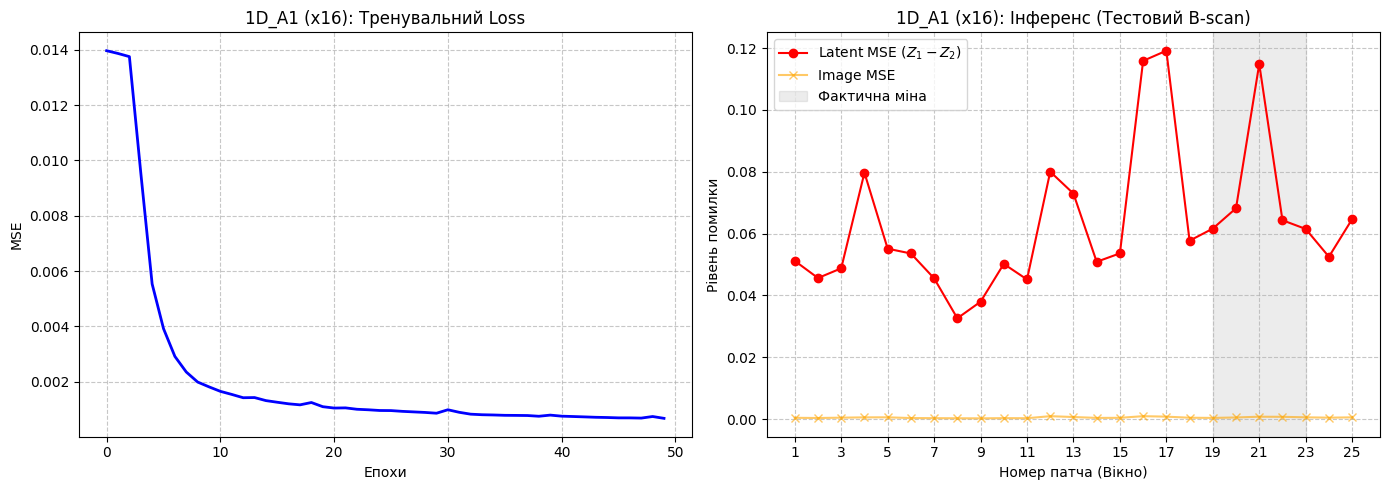

In [37]:
# ==========================================
# ЕТАП Б: ІНФЕРЕНС ТА ВІЗУАЛІЗАЦІЯ
# ==========================================
print("\n=== ЕТАП Б: ІНФЕРЕНС (Тестовий B-scan) ===")

# 1. Проганяємо тестовий лоадер через модель за допомогою нашої утиліти
test_image_mse, test_latent_mse = evaluate_anomaly_detector(model_a1, test_loader, device, criterion_mse)
print(f"Оброблено {len(test_latent_mse)} патчів.")

# 2. Зберігаємо результати у єдину базу JSON
save_model_results(
    channel_type='1_channel', 
    model_key='A1_x16', 
    train_loss=train_loss_history, 
    test_img_mse=test_image_mse, 
    test_lat_mse=test_latent_mse
)

# 3. Миттєва побудова стандартних графіків
plot_model_metrics(
    train_loss=train_loss_history, 
    img_mse=test_image_mse, 
    lat_mse=test_latent_mse, 
    model_name="1D_A1 (x16)"
)

**Опис**<br>
- *Restored image - original image*<br>
В цьому випадку, мережа ідеально відтворила міну після декодигу, так стиснення в 16 разів дало дуже великий простір до запам'ятовування, тому Image MSE (x_hat - x) в області міни показує майже нульову похибку.<br>
- *Latent representation1 - Latent Representation2*<br>
У випадку латентного відображення, похибка росте в місці аномалії не зважаючи на ідеально відтворене зображення.




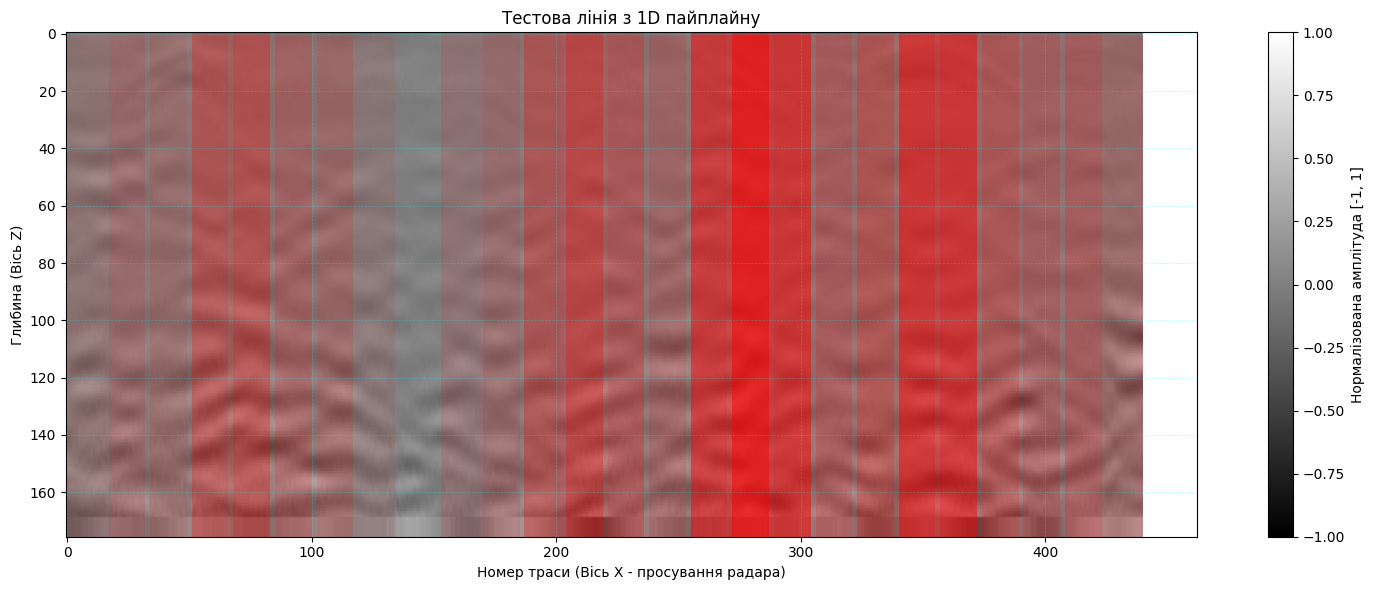

In [38]:
plot_bscan_with_prediction(test_tensor,lat_mse=test_latent_mse, title="Тестова лінія з 1D пайплайну")

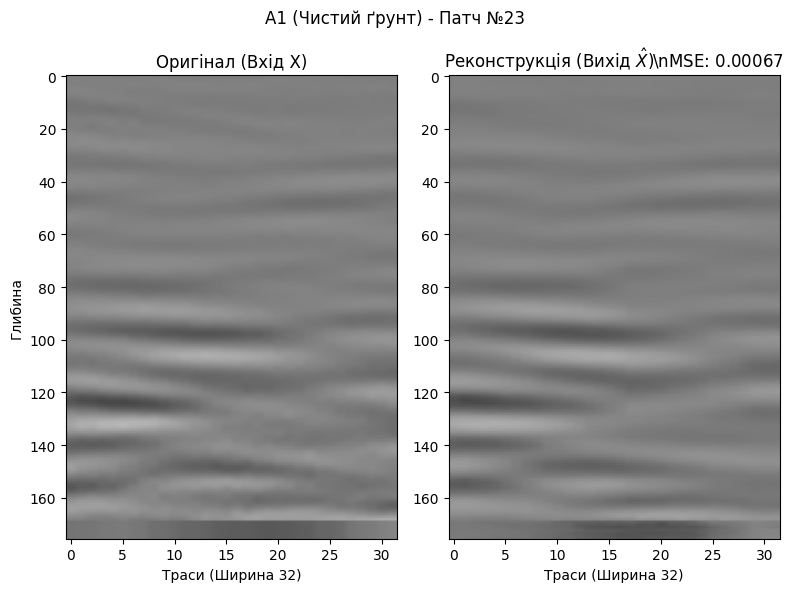

In [22]:
plot_reconstruction_sample(model_a1, test_dataset, device, patch_idx=22, title_prefix="A1 (Чистий ґрунт)")

### Ініціалізація і тренування A2_x32

In [39]:
# ==========================================
# ІНІЦІАЛІЗАЦІЯ МОДЕЛІ A2 (x32)
# ==========================================
print("=== Ініціалізація A2 (Стиснення x32) ===")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_a2 = DualAutoencoder1D_A2().to(device)

epochs = 50
learning_rate = 0.001
optimizer_a2 = optim.Adam(model_a2.parameters(), lr=learning_rate)
criterion_mse = nn.MSELoss()

# Списки для результатів
train_loss_history_a2 = []

=== Ініціалізація A2 (Стиснення x32) ===


In [40]:
# ==========================================
# ЕТАП А: ТРЕНУВАННЯ
# ==========================================
print("\n=== ЕТАП А: ТРЕНУВАННЯ A2_x32 ===")
model_a2.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x in train_loader:
        batch_x = batch_x.to(device)
        
        optimizer_a2.zero_grad()
        # Для тренування потрібен тільки x_hat
        x_hat, _, _ = model_a2(batch_x)
        
        loss = criterion_mse(x_hat, batch_x)
        loss.backward()
        optimizer_a2.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_loss_history_a2.append(avg_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Епоха [{epoch+1:02d}/{epochs}], Loss: {avg_loss:.6f}")


=== ЕТАП А: ТРЕНУВАННЯ A2_x32 ===
Епоха [01/50], Loss: 0.014085
Епоха [10/50], Loss: 0.013757
Епоха [20/50], Loss: 0.001345
Епоха [30/50], Loss: 0.001003
Епоха [40/50], Loss: 0.000881
Епоха [50/50], Loss: 0.000791



=== ЕТАП Б: ІНФЕРЕНС (Тестовий B-scan) ===
Оброблено 25 патчів.
✅ Результати збережено: [1_channel -> A2_x32]


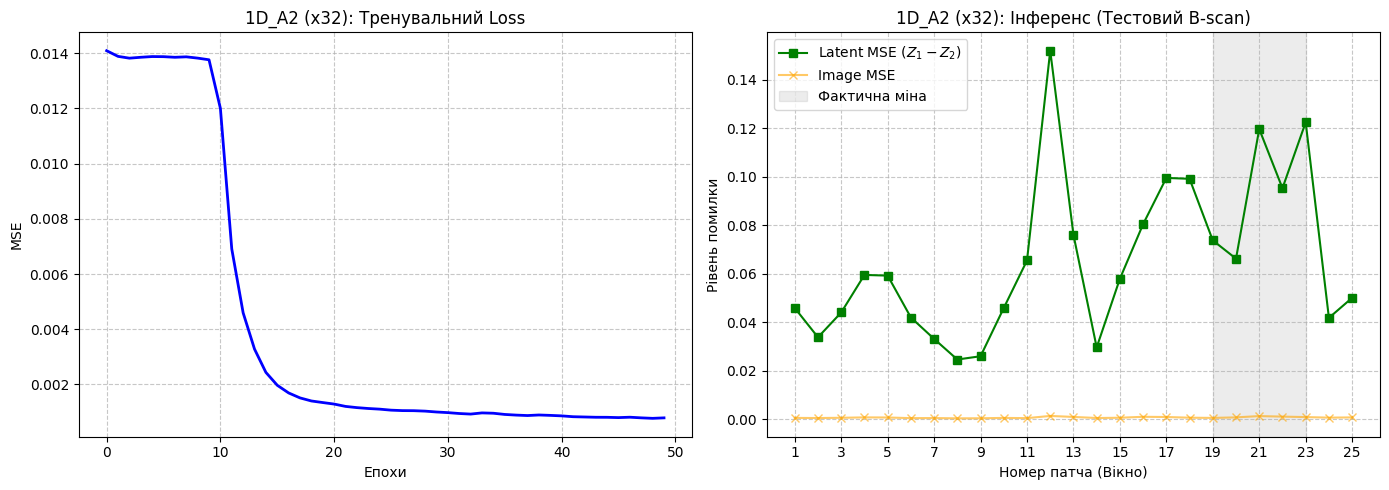

In [41]:
# ==========================================
# ЕТАП Б: ІНФЕРЕНС ТА ВІЗУАЛІЗАЦІЯ
# ==========================================
print("\n=== ЕТАП Б: ІНФЕРЕНС (Тестовий B-scan) ===")

# 1. Проганяємо тестовий лоадер через модель за допомогою нашої утиліти
test_image_mse, test_latent_mse = evaluate_anomaly_detector(model_a2, test_loader, device, criterion_mse)
print(f"Оброблено {len(test_latent_mse)} патчів.")

# 2. Зберігаємо результати у єдину базу JSON
save_model_results(
    channel_type='1_channel', 
    model_key='A2_x32', 
    train_loss=train_loss_history_a2, 
    test_img_mse=test_image_mse, 
    test_lat_mse=test_latent_mse
)

# 3. Миттєва побудова стандартних графіків
plot_model_metrics(
    train_loss=train_loss_history_a2, 
    img_mse=test_image_mse, 
    lat_mse=test_latent_mse, 
    model_name="1D_A2 (x32)"
)

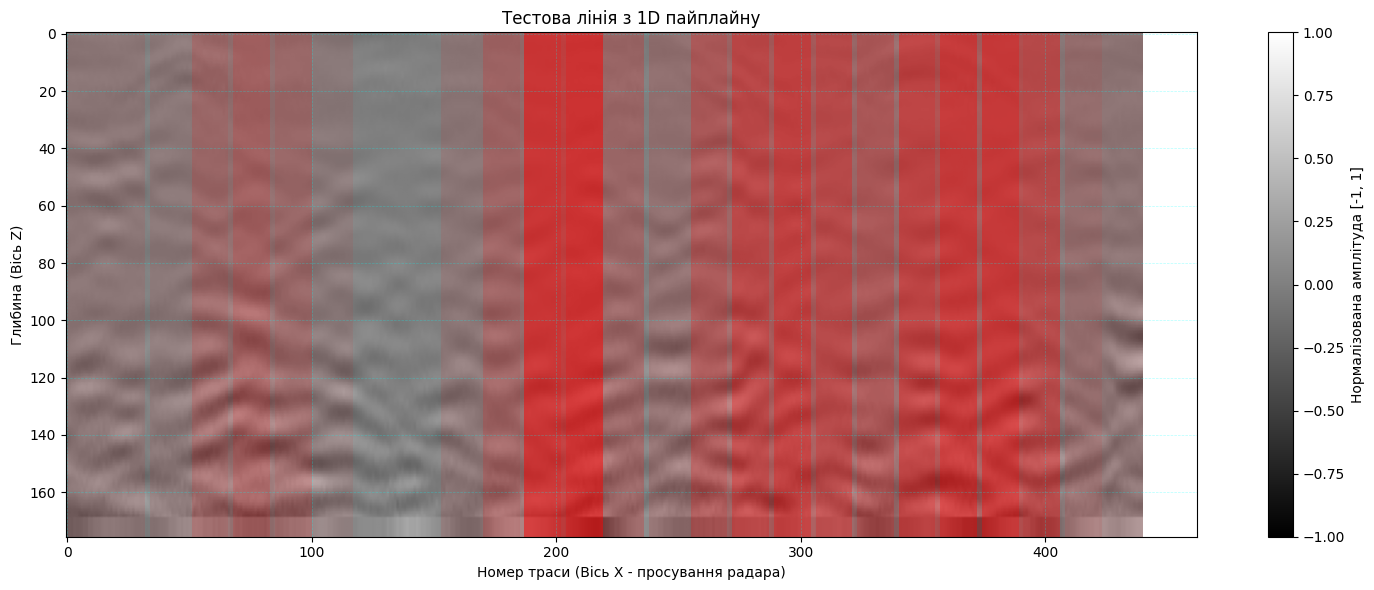

In [42]:
plot_bscan_with_prediction(test_tensor, lat_mse=test_latent_mse, title="Тестова лінія з 1D пайплайну")

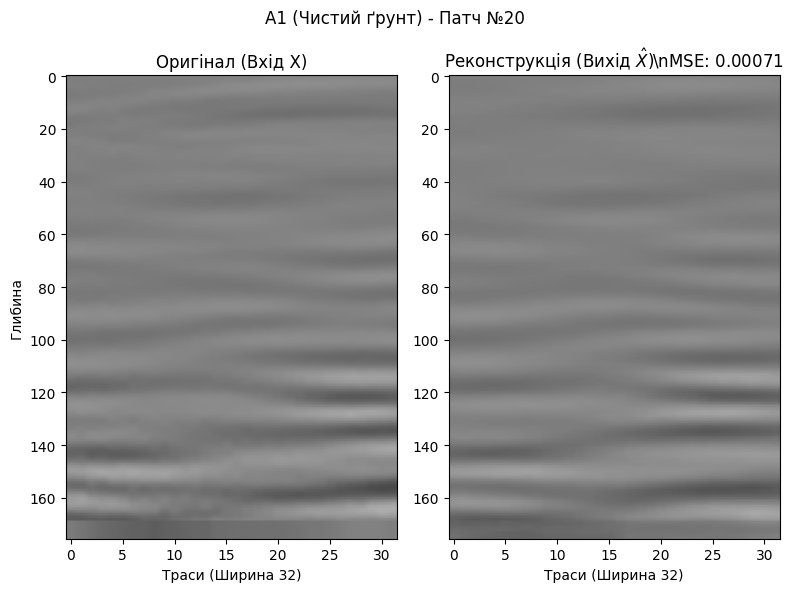

In [43]:
plot_reconstruction_sample(model_a2, test_dataset, device, patch_idx=19, title_prefix="A1 (Чистий ґрунт)")

### Ініціалізація і тренування A2_x64

In [44]:
# ==========================================
# ІНІЦІАЛІЗАЦІЯ МОДЕЛІ A3 (x64)
# ==========================================
print("=== Ініціалізація A3 (Стиснення x64) ===")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_a3 = DualAutoencoder1D_A3().to(device)

epochs = 50
learning_rate = 0.001
optimizer_a3 = optim.Adam(model_a3.parameters(), lr=learning_rate)
criterion_mse = nn.MSELoss()

train_loss_history_a3 = []

=== Ініціалізація A3 (Стиснення x64) ===


In [45]:
# ==========================================
# ЕТАП А: ТРЕНУВАННЯ A3_x64
# ==========================================
print("\n=== ЕТАП А: ТРЕНУВАННЯ A3_x64 ===")
model_a3.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x in train_loader:
        batch_x = batch_x.to(device)
        
        optimizer_a3.zero_grad()
        x_hat, _, _ = model_a3(batch_x)
        
        loss = criterion_mse(x_hat, batch_x)
        loss.backward()
        optimizer_a3.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_loss_history_a3.append(avg_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Епоха [{epoch+1:02d}/{epochs}], Loss: {avg_loss:.6f}")


=== ЕТАП А: ТРЕНУВАННЯ A3_x64 ===
Епоха [01/50], Loss: 0.013915
Епоха [10/50], Loss: 0.005495
Епоха [20/50], Loss: 0.002685
Епоха [30/50], Loss: 0.002041
Епоха [40/50], Loss: 0.001844
Епоха [50/50], Loss: 0.001668



=== ЕТАП Б: ІНФЕРЕНС (Тестовий B-scan) ===
Оброблено 25 патчів.
✅ Результати збережено: [1_channel -> A3_x64]


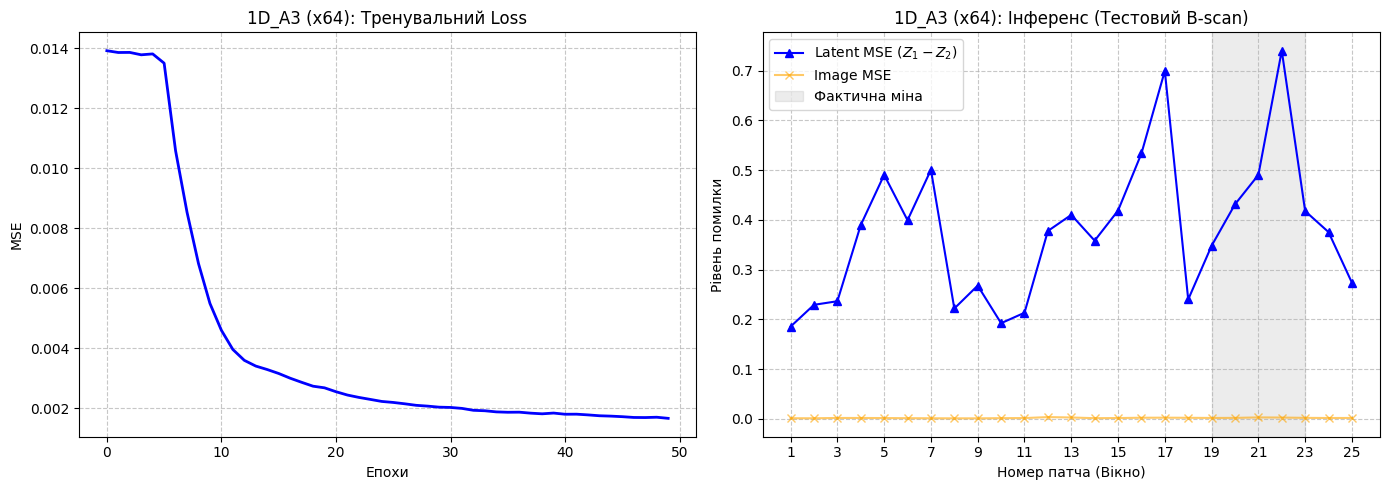

In [58]:
# ==========================================
# ЕТАП Б: ІНФЕРЕНС ТА ВІЗУАЛІЗАЦІЯ
# ==========================================
print("\n=== ЕТАП Б: ІНФЕРЕНС (Тестовий B-scan) ===")

# 1. Проганяємо тестовий лоадер через модель за допомогою нашої утиліти
test_image_mse, test_latent_mse = evaluate_anomaly_detector(model_a3, test_loader, device, criterion_mse)
print(f"Оброблено {len(test_latent_mse)} патчів.")

# 2. Зберігаємо результати у єдину базу JSON
save_model_results(
    channel_type='1_channel', 
    model_key='A3_x64', 
    train_loss=train_loss_history_a3, 
    test_img_mse=test_image_mse, 
    test_lat_mse=test_latent_mse
)

# 3. Миттєва побудова стандартних графіків
plot_model_metrics(
    train_loss=train_loss_history_a3, 
    img_mse=test_image_mse, 
    lat_mse=test_latent_mse, 
    model_name="1D_A3 (x64)"
)

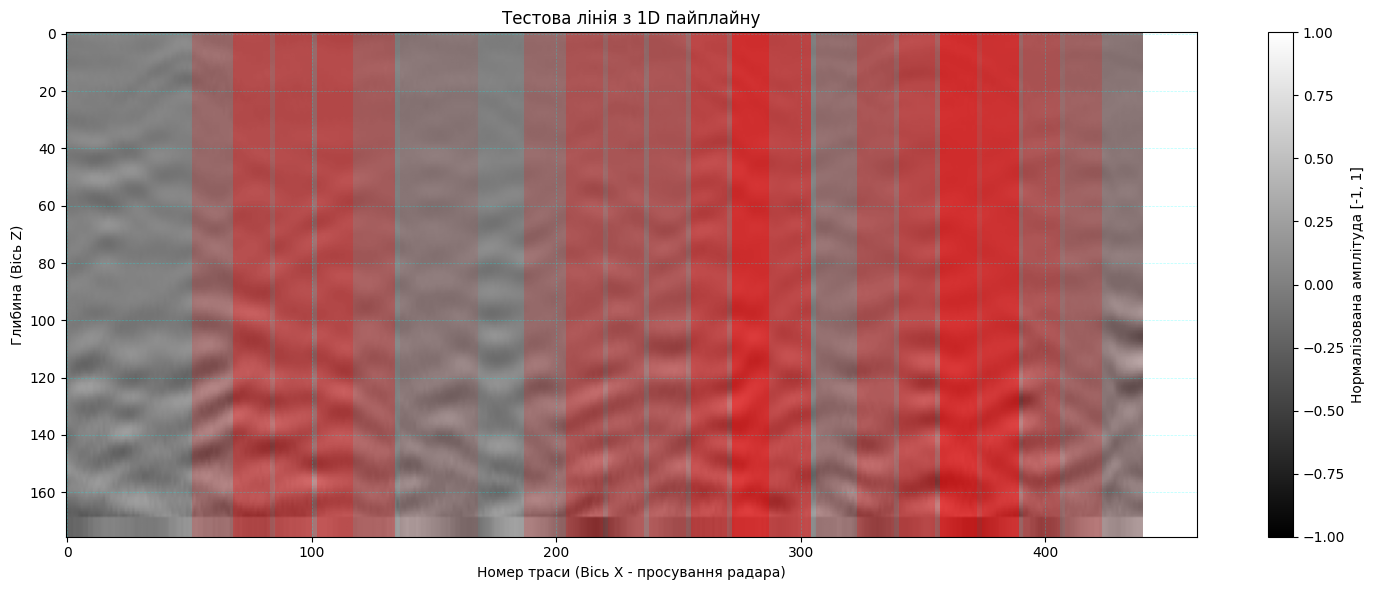

In [59]:
plot_bscan_with_prediction(test_tensor, lat_mse=test_latent_mse, title="Тестова лінія з 1D пайплайну")

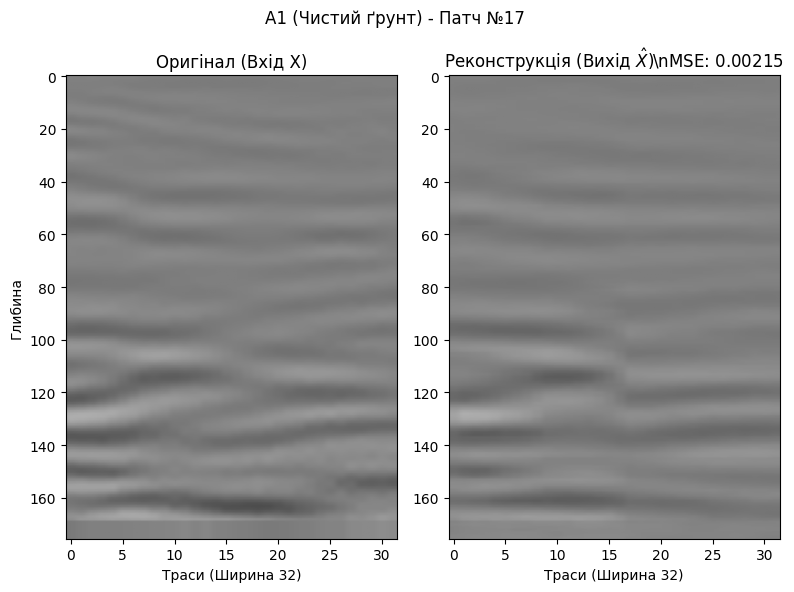

In [62]:
plot_reconstruction_sample(model_a3, test_dataset, device, patch_idx=16, title_prefix="A1 (Чистий ґрунт)")

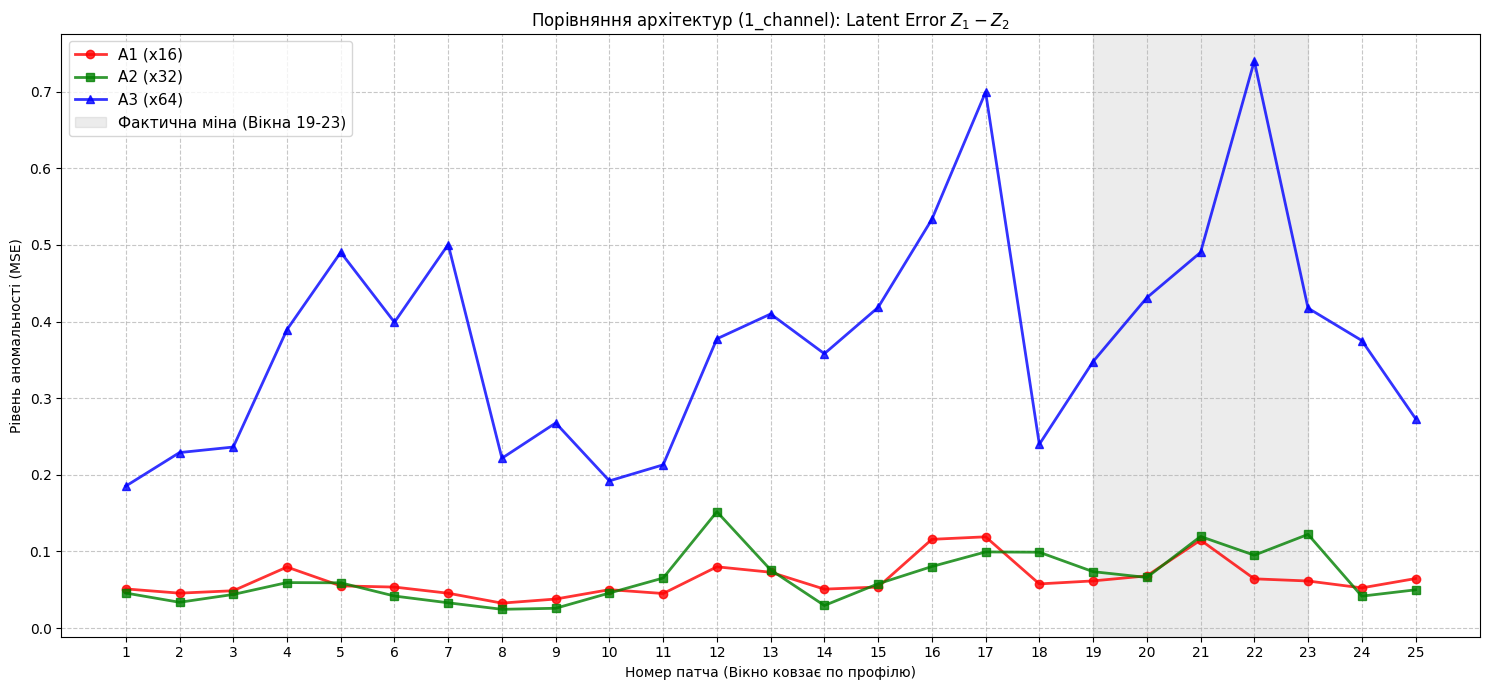

In [60]:
plot_comparison_from_json(RESULTS_FILE, channel_type='1_channel')

## Категорія 2: 3 канали (Псевдо-3D/3 канали)
Імітація роботи із RGB-зображенням.
- **Вхід:** Три однакові патчі з трьох сусідніх В-сканів (лінії *i-1, i, i+1*), накладені один на одного
- **Формат тензора:** `(Batch_Size, 3, 176, 32)` - де 3 це канали, як в RGB
- **Мета тесту:** Перевірити гіпотезу зі статті. Мережа має навчитися розуміти, що справжній об'єкт (як труба чи велика міна) має "відлуння" на сусідніх лініях сканування, а випадковий камінь - ні. Це має різко зменшити кількість хибних спрацьовувань (False Positives).

In [64]:
class GPR3DDataset(Dataset):
    def __init__(self, tensor_3d, window_size=32, step=17):
        """
        tensor_3d: Неперервний масив B-сканів. Розмірність (Lines, Depth, Width).
        Для 3-канального підходу потрібно МІНІМУМ 3 лінії.
        """
        self.data = tensor_3d
        self.window_size = window_size
        self.step = step
        
        self.num_lines = tensor_3d.shape[0]
        self.width = tensor_3d.shape[2]
        
        if self.num_lines < 3:
            raise ValueError(f"Для 3D датасету потрібно мінімум 3 лінії, передано {self.num_lines}")
            
        # Кількість ліній, які можуть бути ЦЕНТРАЛЬНИМИ (мають сусіда з обох боків)
        self.valid_center_lines = self.num_lines - 2
        
        self.patches_per_line = (self.width - self.window_size) // self.step + 1
        self.total_patches = self.valid_center_lines * self.patches_per_line

    def __len__(self):
        return self.total_patches

    def __getitem__(self, idx):
        # 1. Визначаємо, яка лінія є центральною (починаємо з індексу 1, а не 0)
        center_line_idx = (idx // self.patches_per_line) + 1 
        
        # 2. Визначаємо, який це по рахунку патч у цій лінії
        patch_idx = idx % self.patches_per_line
        start_col = patch_idx * self.step
        
        # 3. ВИРІЗАЄМО 3 КАНАЛИ ОДНОЧАСНО (попередня, центральна, наступна)
        # self.data[0:3] виріже лінії 0, 1, 2.
        patch_3d = self.data[center_line_idx - 1 : center_line_idx + 2, :, start_col : start_col + self.window_size]
        
        # Результат вже має розмірність (3, 176, 32). Додавати unsqueeze(0) як раніше НЕ ТРЕБА.
        return torch.tensor(patch_3d, dtype=torch.float32).clone()

In [67]:
train_block_1 = train_tensor[0:9]
train_block_2 = train_tensor[9:12]

In [69]:
print(f"Блок 1 (9 ліній): {train_block_1.shape}")
print(f"Блок 2 (3 лінії): {train_block_2.shape}\n")

dataset_block_1 = GPR3DDataset(train_block_1, window_size=32, step=17)
dataset_block_2 = GPR3DDataset(train_block_2, window_size=32, step=17)

print(f"Патчів у Блоці 1: {len(dataset_block_1)} (Це 7 робочих ліній)")
print(f"Патчів у Блоці 2: {len(dataset_block_2)} (Це 1 робоча лінія)")

train_dataset_3d = ConcatDataset([dataset_block_1, dataset_block_2])
train_loader_3d = DataLoader(train_dataset_3d, batch_size=16, shuffle=True)

print(f"Загалом 3-канальних патчів для тренування: {len(train_dataset_3d)}")
print(f"Кількість батчів на епоху: {len(train_loader_3d)}")

Блок 1 (9 ліній): (9, 176, 440)
Блок 2 (3 лінії): (3, 176, 440)

Патчів у Блоці 1: 175 (Це 7 робочих ліній)
Патчів у Блоці 2: 25 (Це 1 робоча лінія)
Загалом 3-канальних патчів для тренування: 200
Кількість батчів на епоху: 13


### Обробка тестового датасету

In [73]:
raw_test_block = data[test_line_idx - 1 : test_line_idx + 2] 

# 1. Background removal (NumPy автоматично застосує це до кожної з 3 ліній окремо)
mean_test_trace = np.mean(raw_test_block, axis=2, keepdims=True)
bg_removed_test = raw_test_block - mean_test_trace

# 2. TVG (використовуємо ту саму альфу)
tvg_applied_test = bg_removed_test * gain_curve 

# 3. Нормалізація (ділимо на той самий max_val з тренувального сету)
test_norm = tvg_applied_test / max_val

# 4. Padding (додаємо 6 відліків знизу до кожної лінії)
# Важливо: pad_width має бути налаштований як ((0,0), (0,6), (0,0)) для 3D масиву
test_tensor_3d = np.pad(test_norm, pad_width, mode='edge')
print(f"Тестовий 3D тензор готовий: {test_tensor_3d.shape}")

Тестовий 3D тензор готовий: (3, 176, 440)


In [74]:
# ==========================================
# СТВОРЕННЯ DATALOADER ДЛЯ 3 КАНАЛІВ
# ==========================================
test_dataset_3d = GPR3DDataset(test_tensor_3d, window_size=32, step=17)

test_loader_3d = DataLoader(test_dataset_3d, batch_size=1, shuffle=False)

sample_patch = test_dataset_3d[0]
print(f"Кількість тестових патчів: {len(test_dataset_3d)}")
print(f"Розмірність одного патча: {sample_patch.shape}")

Кількість тестових патчів: 25
Розмірність одного патча: torch.Size([3, 176, 32])


### Архітектура моделей

In [75]:
# ==========================================
# 1. Модель 3D_A1 (Стиснення x16)
# ==========================================
class DualAutoencoder3D_A1(nn.Module):
    def __init__(self):
        super(DualAutoencoder3D_A1, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(), # ЗМІНЕНО: 3 вхідних канали
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU()  # Ботлнек: 16 каналів
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(16, 3, kernel_size=3, stride=1, padding=1), nn.Tanh() # ЗМІНЕНО: 3 вихідних канали
        )
    def forward(self, x):
        z1 = self.encoder(x)          
        x_hat = self.decoder(z1)      
        z2 = self.encoder(x_hat)      
        return x_hat, z1, z2


# ==========================================
# 2. Модель 3D_A2 (Стиснення x32)
# ==========================================
class DualAutoencoder3D_A2(nn.Module):
    def __init__(self):
        super(DualAutoencoder3D_A2, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(), # ЗМІНЕНО
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1), nn.ReLU()   # Ботлнек: 8 каналів
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(16, 3, kernel_size=3, stride=1, padding=1), nn.Tanh() # ЗМІНЕНО
        )
    def forward(self, x):
        z1 = self.encoder(x)
        x_hat = self.decoder(z1)
        z2 = self.encoder(x_hat)
        return x_hat, z1, z2


# ==========================================
# 3. Модель 3D_A3 (Стиснення x64)
# ==========================================
class DualAutoencoder3D_A3(nn.Module):
    def __init__(self):
        super(DualAutoencoder3D_A3, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(), # ЗМІНЕНО
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 4, kernel_size=3, stride=2, padding=1), nn.ReLU()   # Ботлнек: 4 канали
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(16, 3, kernel_size=3, stride=1, padding=1), nn.Tanh() # ЗМІНЕНО
        )
    def forward(self, x):
        z1 = self.encoder(x)
        x_hat = self.decoder(z1)
        z2 = self.encoder(x_hat)
        return x_hat, z1, z2

### Ініціалізація і тренування A1_x16

In [76]:
# ==========================================
# ІНІЦІАЛІЗАЦІЯ МОДЕЛІ 3D_A1
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ініціалізуємо 3-канальну модель
model_3d_a1 = DualAutoencoder3D_A1().to(device)
epochs = 50
optimizer = optim.Adam(model_3d_a1.parameters(), lr=0.001)
criterion_mse = nn.MSELoss()

In [77]:
# ==========================================
# ЕТАП А: ТРЕНУВАННЯ
# ==========================================
print("\n=== ЕТАП А: ТРЕНУВАННЯ 3D_A1 (x16) ===")
train_loss_history_3d_a1 = []
model_3d_a1.train()

# Використовуємо train_loader_3d (він вже містить склеєні 3-канальні дані)
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x in train_loader_3d:
        batch_x = batch_x.to(device)
        optimizer.zero_grad()
        
        # Прогін через 3-канальну модель
        x_hat, _, _ = model_3d_a1(batch_x) 
        
        loss = criterion_mse(x_hat, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader_3d)
    train_loss_history_3d_a1.append(avg_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Епоха [{epoch+1:02d}/{epochs}], Loss: {avg_loss:.6f}")


=== ЕТАП А: ТРЕНУВАННЯ 3D_A1 (x16) ===
Епоха [01/50], Loss: 0.014773
Епоха [10/50], Loss: 0.007816
Епоха [20/50], Loss: 0.004673
Епоха [30/50], Loss: 0.004517
Епоха [40/50], Loss: 0.004349
Епоха [50/50], Loss: 0.004288



=== ЕТАП Б: ІНФЕРЕНС (Тестовий 3D B-scan) ===
Оброблено 25 патчів.
✅ Результати збережено: [3_channel -> A1_x16]


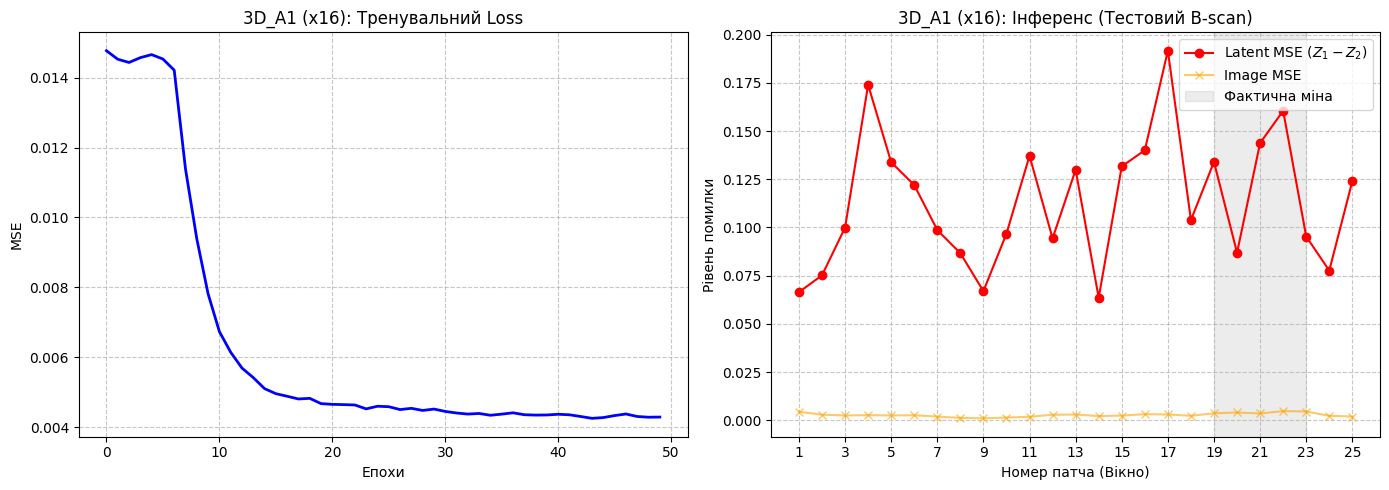

In [78]:
print("\n=== ЕТАП Б: ІНФЕРЕНС (Тестовий 3D B-scan) ===")

# 1. Проганяємо 3D тестовий лоадер через модель за допомогою нашої утиліти
test_image_mse_3d_a1, test_latent_mse_3d_a1 = evaluate_anomaly_detector(
    model_3d_a1, test_loader_3d, device, criterion_mse
)
print(f"Оброблено {len(test_latent_mse_3d_a1)} патчів.")

# 2. Зберігаємо результати у нову категорію JSON: '3_channel'
save_model_results(
    channel_type='3_channel', 
    model_key='A1_x16', 
    train_loss=train_loss_history_3d_a1, 
    test_img_mse=test_image_mse_3d_a1, 
    test_lat_mse=test_latent_mse_3d_a1
)

# 3. Миттєва побудова стандартних графіків
plot_model_metrics(
    train_loss=train_loss_history_3d_a1, 
    img_mse=test_image_mse_3d_a1, 
    lat_mse=test_latent_mse_3d_a1, 
    model_name="3D_A1 (x16)"
)

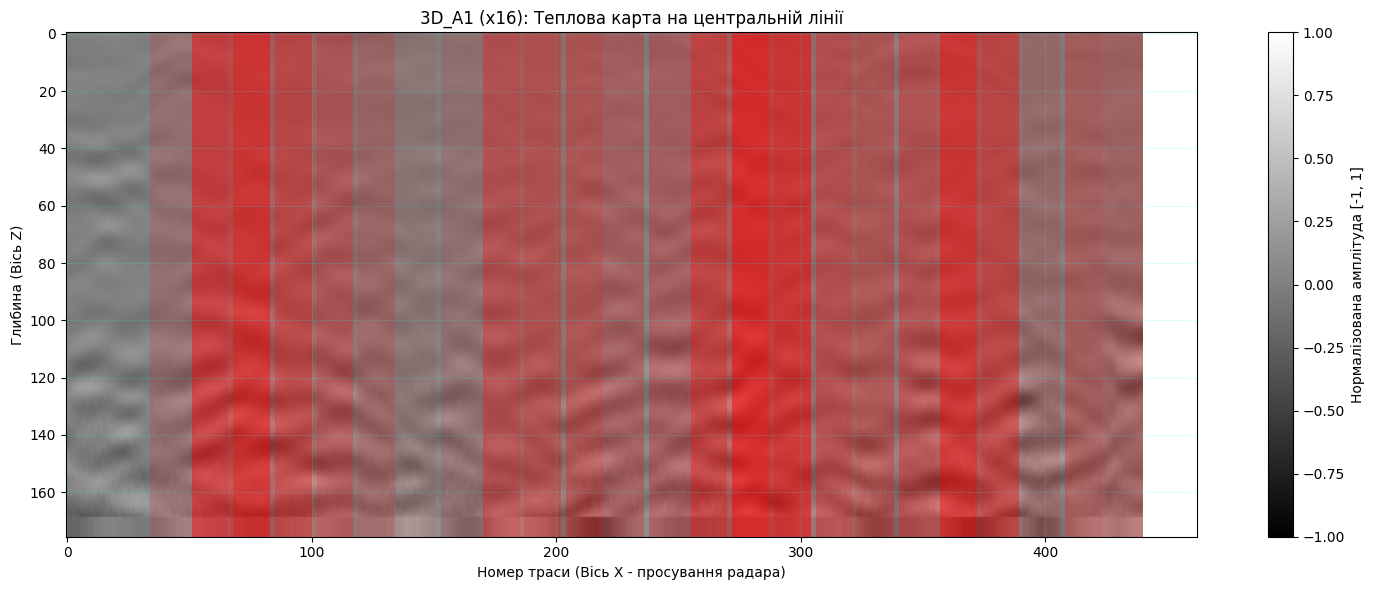

In [80]:
central_bscan = test_tensor_3d[1]

plot_bscan_with_prediction(
    tensor_data=central_bscan, 
    lat_mse=test_latent_mse_3d_a1, 
    title="3D_A1 (x16): Теплова карта на центральній лінії"
)

### Ініціалізація і тренування A2_x32

In [81]:
# ==========================================
# ІНІЦІАЛІЗАЦІЯ МОДЕЛІ 3D_A2
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ініціалізуємо 3-канальну модель A2
model_3d_a2 = DualAutoencoder3D_A2().to(device)
epochs = 50
optimizer_a2 = optim.Adam(model_3d_a2.parameters(), lr=0.001)
criterion_mse = nn.MSELoss()

In [82]:
# ==========================================
# ЕТАП А: ТРЕНУВАННЯ
# ==========================================
print("\n=== ЕТАП А: ТРЕНУВАННЯ 3D_A2 (x32) ===")
train_loss_history_3d_a2 = []
model_3d_a2.train()

# Використовуємо train_loader_3d 
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x in train_loader_3d:
        batch_x = batch_x.to(device)
        optimizer_a2.zero_grad()
        
        # Прогін через 3-канальну модель A2
        x_hat, _, _ = model_3d_a2(batch_x) 
        
        loss = criterion_mse(x_hat, batch_x)
        loss.backward()
        optimizer_a2.step()
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader_3d)
    train_loss_history_3d_a2.append(avg_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Епоха [{epoch+1:02d}/{epochs}], Loss: {avg_loss:.6f}")


=== ЕТАП А: ТРЕНУВАННЯ 3D_A2 (x32) ===
Епоха [01/50], Loss: 0.015348
Епоха [10/50], Loss: 0.014581
Епоха [20/50], Loss: 0.005245
Епоха [30/50], Loss: 0.004644
Епоха [40/50], Loss: 0.004526
Епоха [50/50], Loss: 0.004400



=== ЕТАП Б: ІНФЕРЕНС (Тестовий 3D B-scan) ===
Оброблено 25 патчів.
✅ Результати збережено: [3_channel -> A2_x32]


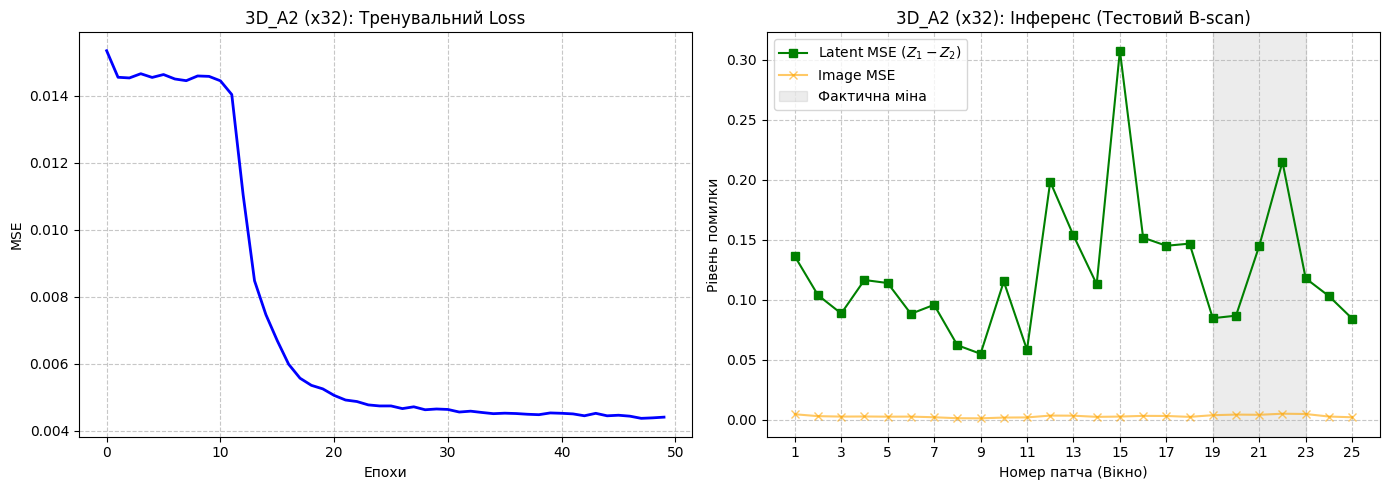

In [83]:
# ==========================================
# ЕТАП Б: ІНФЕРЕНС ТА ВІЗУАЛІЗАЦІЯ
# ==========================================
print("\n=== ЕТАП Б: ІНФЕРЕНС (Тестовий 3D B-scan) ===")

# 1. Проганяємо 3D тестовий лоадер через модель за допомогою нашої утиліти
test_image_mse_3d_a2, test_latent_mse_3d_a2 = evaluate_anomaly_detector(
    model_3d_a2, test_loader_3d, device, criterion_mse
)
print(f"Оброблено {len(test_latent_mse_3d_a2)} патчів.")

# 2. Зберігаємо результати у категорію JSON: '3_channel'
save_model_results(
    channel_type='3_channel', 
    model_key='A2_x32', 
    train_loss=train_loss_history_3d_a2, 
    test_img_mse=test_image_mse_3d_a2, 
    test_lat_mse=test_latent_mse_3d_a2
)

# 3. Миттєва побудова стандартних графіків
plot_model_metrics(
    train_loss=train_loss_history_3d_a2, 
    img_mse=test_image_mse_3d_a2, 
    lat_mse=test_latent_mse_3d_a2, 
    model_name="3D_A2 (x32)"
)

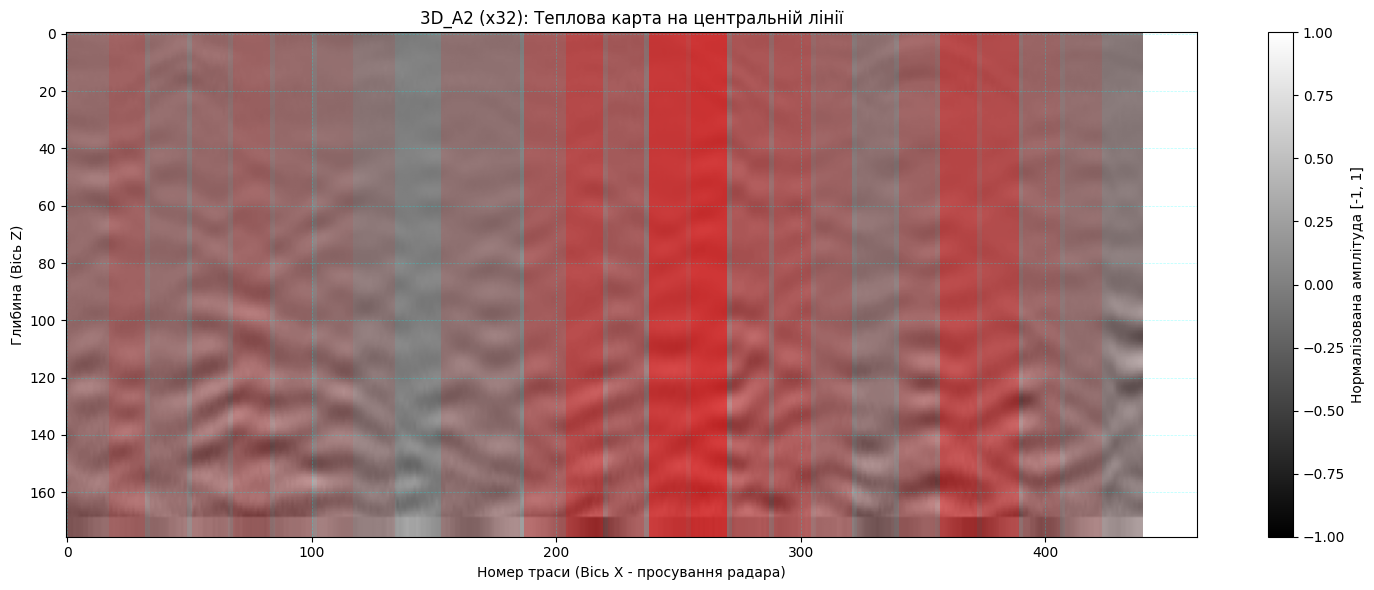

In [84]:
central_bscan = test_tensor_3d[1]

plot_bscan_with_prediction(
    tensor_data=central_bscan, 
    lat_mse=test_latent_mse_3d_a2, 
    title="3D_A2 (x32): Теплова карта на центральній лінії"
)

### Ініціалізація і тренування A3_x64

In [85]:
# ==========================================
# ІНІЦІАЛІЗАЦІЯ МОДЕЛІ 3D_A3
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ініціалізуємо 3-канальну модель A3
model_3d_a3 = DualAutoencoder3D_A3().to(device)
epochs = 50
optimizer_a3 = optim.Adam(model_3d_a3.parameters(), lr=0.001)
criterion_mse = nn.MSELoss()

In [86]:
# ==========================================
# ЕТАП А: ТРЕНУВАННЯ
# ==========================================
print("\n=== ЕТАП А: ТРЕНУВАННЯ 3D_A3 (x64) ===")
train_loss_history_3d_a3 = []
model_3d_a3.train()

# Використовуємо train_loader_3d 
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x in train_loader_3d:
        batch_x = batch_x.to(device)
        optimizer_a3.zero_grad()
        
        # Прогін через 3-канальну модель A3
        x_hat, _, _ = model_3d_a3(batch_x) 
        
        loss = criterion_mse(x_hat, batch_x)
        loss.backward()
        optimizer_a3.step()
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader_3d)
    train_loss_history_3d_a3.append(avg_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Епоха [{epoch+1:02d}/{epochs}], Loss: {avg_loss:.6f}")


=== ЕТАП А: ТРЕНУВАННЯ 3D_A3 (x64) ===
Епоха [01/50], Loss: 0.016633
Епоха [10/50], Loss: 0.012764
Епоха [20/50], Loss: 0.007331
Епоха [30/50], Loss: 0.006504
Епоха [40/50], Loss: 0.006288
Епоха [50/50], Loss: 0.006001



=== ЕТАП Б: ІНФЕРЕНС (Тестовий 3D B-scan) ===
Оброблено 25 патчів.
✅ Результати збережено: [3_channel -> A3_x64]


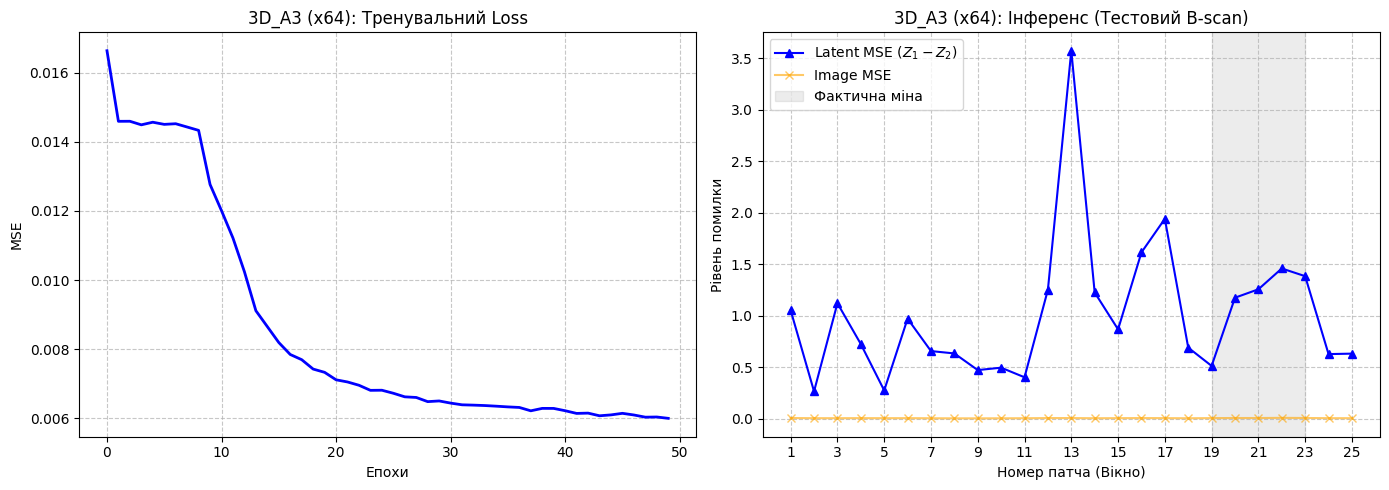

In [87]:
# ==========================================
# ЕТАП Б: ІНФЕРЕНС ТА ВІЗУАЛІЗАЦІЯ
# ==========================================
print("\n=== ЕТАП Б: ІНФЕРЕНС (Тестовий 3D B-scan) ===")

# 1. Проганяємо 3D тестовий лоадер через модель за допомогою нашої утиліти
test_image_mse_3d_a3, test_latent_mse_3d_a3 = evaluate_anomaly_detector(
    model_3d_a3, test_loader_3d, device, criterion_mse
)
print(f"Оброблено {len(test_latent_mse_3d_a3)} патчів.")

# 2. Зберігаємо результати у категорію JSON: '3_channel'
save_model_results(
    channel_type='3_channel', 
    model_key='A3_x64', 
    train_loss=train_loss_history_3d_a3, 
    test_img_mse=test_image_mse_3d_a3, 
    test_lat_mse=test_latent_mse_3d_a3
)

# 3. Миттєва побудова стандартних графіків
plot_model_metrics(
    train_loss=train_loss_history_3d_a3, 
    img_mse=test_image_mse_3d_a3, 
    lat_mse=test_latent_mse_3d_a3, 
    model_name="3D_A3 (x64)"
)

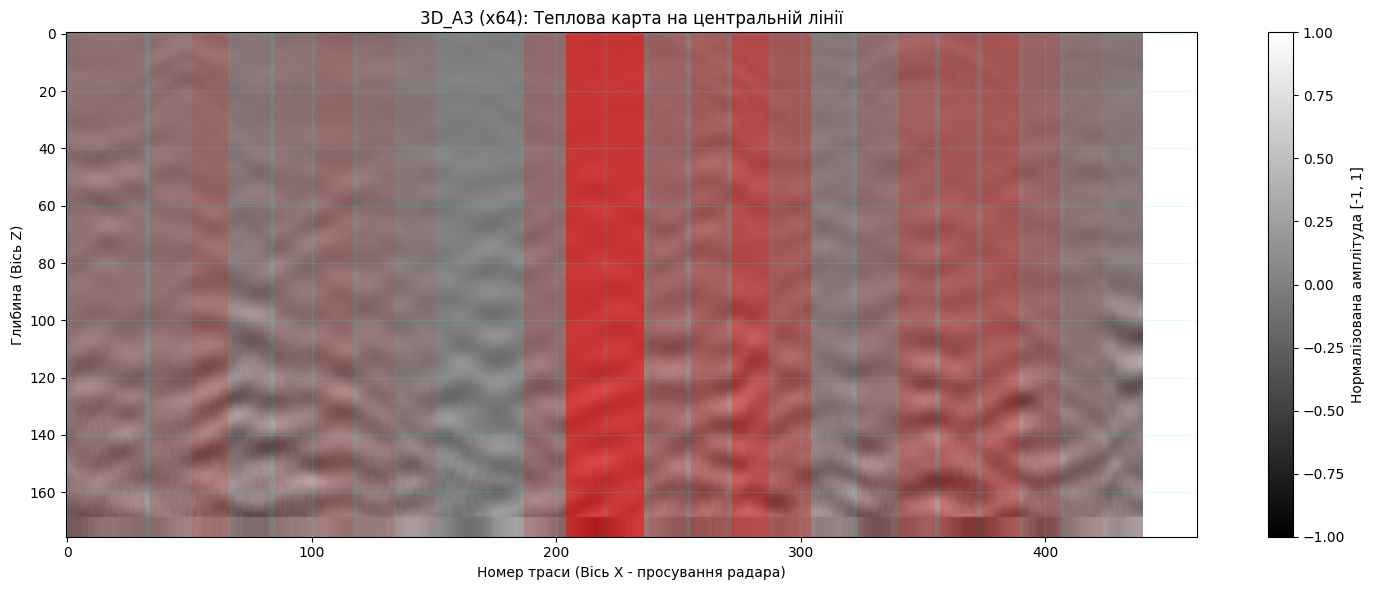

In [88]:
# ==========================================
# 4. ТЕПЛОВА КАРТА НА ЦЕНТРАЛЬНОМУ B-SCAN
# ==========================================
# Беремо центральний зріз (індекс 1) з 3-х каналів тестового тензора
central_bscan = test_tensor_3d[1]

plot_bscan_with_prediction(
    tensor_data=central_bscan, 
    lat_mse=test_latent_mse_3d_a3, 
    title="3D_A3 (x64): Теплова карта на центральній лінії"
)

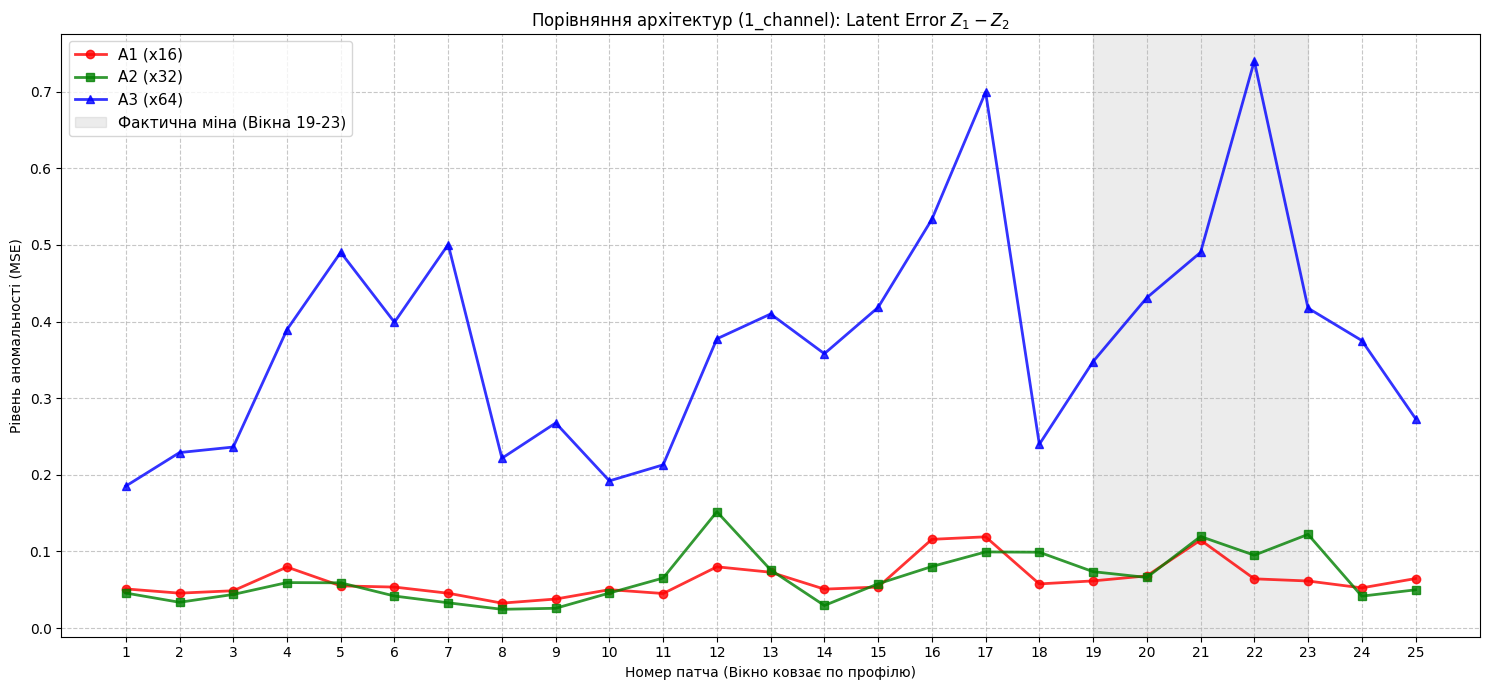

In [90]:
plot_comparison_from_json(RESULTS_FILE, channel_type='1_channel')

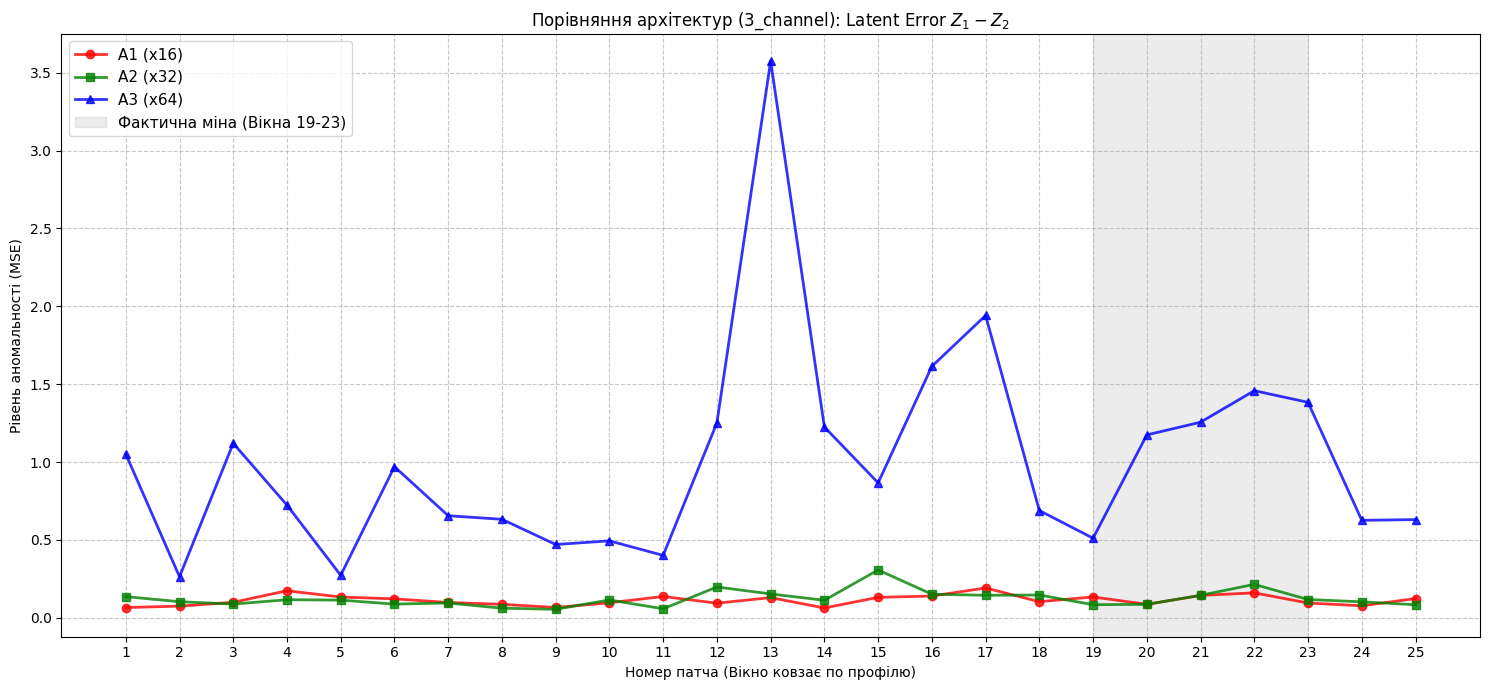

In [89]:
plot_comparison_from_json(RESULTS_FILE, channel_type='3_channel')

## Категорія 3: 5 каналів (Розширене псевдо-3D/5 канали)
Модифікація для пошуку великих або протяжних об'єктів (наприклад, протитанкових мін (ТМ-62)  або довгого будівельного сміття)
- **Вхід:** П'ять патчів із п'яти сусідніх В-сканів (лінії *i-2, i-1, i, i+1, i+2*).
- **Формат тензора:** `(Batch_Size, 5, 176, 32)`.
- **Технічний нюанс:** Оскільки береться вікно з 5 ліній, неможливо відцентрувати його на перших і останніх двох лініях датасету. Ці краї доведеться ігнорувати під час тренування. Враховуючи всього 12  ліній без мін, з них стоять поряд 9 та 3, можливість тренування дуже обмежена. 
- **Мета тесту:** Перевірити, чи дає розширення просторового контексту до 5 ліній приріст точності, чи просто уповільнює навчання і перевантажує латентний простір сміттям. 